In [2]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from math import pi as PI
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# for difference between np.polyfit ans sklearn PolynomialFreatures see:
# https://towardsdatascience.com/polynomial-regression-with-scikit-learn-what-you-should-know-bed9d3296f2
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from mlxtend.evaluate import bias_variance_decomp

# From sklearn tutorial

In [2]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

In [3]:
(y_true - y_pred)**2

array([0.25, 0.25, 0.  , 1.  ])

In [4]:
((y_true - y_pred)**2).mean()

0.375

In [5]:
mean_squared_error(y_true, y_pred)

0.375

# Data generation

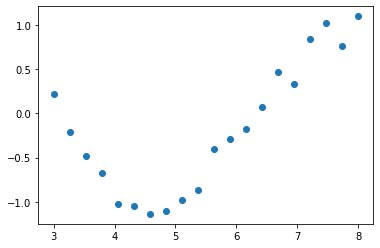

In [9]:
# number of observations
NUM_OBS = 20

# generate 20 random observations
x = np.linspace(3, 8, NUM_OBS)
y = np.sin(x) + np.random.normal(0, 0.2, NUM_OBS)

# plot x vs y
plt.plot(x, y, 'o')

# Modelling

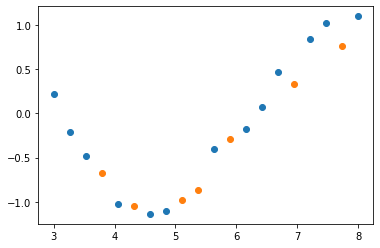

In [10]:
# split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33)

# plot training and testing sets
plt.plot(x_train, y_train, 'o')
plt.plot(x_test, y_test, 'o')

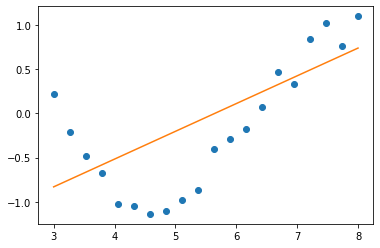

In [22]:
# fit polynomial regression model
# degree of polynomial
poly_deg = 1

# fit model with sklearn
model = make_pipeline(PolynomialFeatures(poly_deg),LinearRegression())
model.fit(x_train.reshape(-1, 1), y_train)
plt.plot(x, y, 'o')
plt.plot(x, model.predict(x.reshape(-1, 1)), '-')

In [23]:
# compute train and test MSE  (mean squared error)
y_train_pred = model.predict(x_train.reshape(-1, 1))
y_test_pred = model.predict(x_test.reshape(-1, 1))

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print('MSE from sklearn')
print(train_mse, test_mse)
# perform bias-variance decomposition
print()
print('MSE, Bias and Variance from mlxtend')
mse, bias, variance = bias_variance_decomp(model, x_train.reshape(-1, 1), y_train, x_test.reshape(-1, 1), y_test, loss='mse', num_rounds=100, random_seed=1)
print(mse, bias, variance)

MSE from sklearn
0.2937520658697829 0.2585835888785249

MSE, Bias and Variance from mlxtend
0.27551475427951355 0.23415622276973608 0.041358531509777446


# Multiple iterations (polynomials of higher order)

In [15]:
num_models = 25
mse_list = []
bias_list = []
variance_list = []
bias_variance_list = []
min_model = 1

for k in range(min_model, num_models):
    # fit model with sklearn
    model = make_pipeline(PolynomialFeatures(k+1),LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)

    y_train_pred = model.predict(x_train.reshape(-1, 1))
    y_test_pred = model.predict(x_test.reshape(-1, 1))

    # perform bias-variance decomposition
    mse, bias, variance = bias_variance_decomp(model, x_train.reshape(-1, 1), y_train, x_test.reshape(-1, 1), y_test, loss='mse', num_rounds=100, random_seed=1)

    mse_list.append(mse)
    bias_list.append(bias)
    variance_list.append(variance)
    bias_variance_list.append(bias/variance)

Text(0, 0.5, 'Bias-variance trade-off')

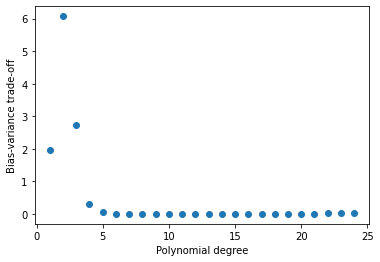

In [16]:
# plot bias-variance trade-off
plt.plot(range(min_model, num_models), bias_variance_list, 'o')
plt.xlabel('Polynomial degree')
plt.ylabel('Bias-variance trade-off')


Text(0, 0.5, 'MSE')

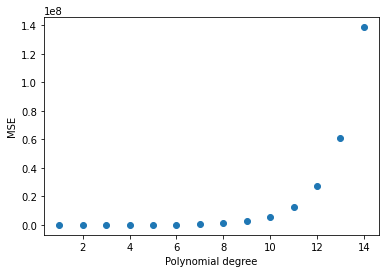

In [54]:
plt.plot(range(min_model, num_models), mse_list, 'o')
plt.xlabel('Polynomial degree')
plt.ylabel('MSE')

Text(0, 0.5, 'bias')

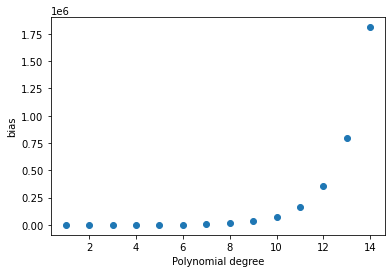

In [55]:
plt.plot(range(min_model, num_models), bias_list, 'o')
plt.xlabel('Polynomial degree')
plt.ylabel('bias')

Text(0, 0.5, 'Variance')

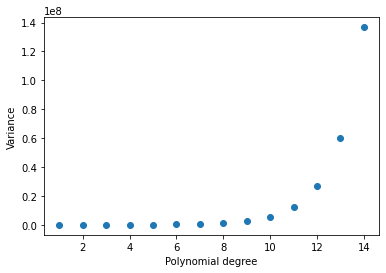

In [56]:
plt.plot(range(min_model, num_models), variance_list, 'o')
plt.xlabel('Polynomial degree')
plt.ylabel('Variance')